In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Các mô hình nâng cao (Advanced Models)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Metric đánh giá (Bao gồm R2 Score)
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score

# Đảm bảo thư mục lưu kết quả tồn tại theo yêu cầu cấu trúc dự án
os.makedirs('./results/model_comparison', exist_ok=True)
print("Thư mục /results/model_comparison đã sẵn sàng.")

Thư mục /results/model_comparison đã sẵn sàng.


In [2]:
import pandas as pd
import numpy as np
import re

# ĐÃ SỬA LỖI: Cập nhật đường dẫn lùi 2 bước (../../) để chỉ đúng vào thư mục data của nhóm
train_df = pd.read_csv('../../data/processed/train_v2.csv')
test_df = pd.read_csv('../../data/processed/test_v2.csv')

# Hàm loại bỏ các ký tự đặc biệt JSON trong tên cột để tránh lỗi LightGBM
def sanitize_column_names(df):
    # Thay thế các ký tự [ ], {, }, :, , và " thành dấu gạch dưới _
    df.columns = [re.sub(r'[\[\]\,\{\}\:\"]', '_', col) for col in df.columns]
    return df

# Tiến hành làm sạch tên cột cho cả 2 tập dữ liệu
train_df = sanitize_column_names(train_df)
test_df = sanitize_column_names(test_df)

# Xác định cột Target là 'Price'
target_col = 'Price'

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

# Khôi phục giá trị thực tế của Price về đơn vị gốc bằng expm1 (vì trước đó dùng log transform)
y_test_actual = np.expm1(y_test)

print("Kích thước tập Train:", X_train.shape)
print("Kích thước tập Test:", X_test.shape)
print("Đã tải dữ liệu thành công và xử lý xong tên cột!")

Kích thước tập Train: (38450, 73)
Kích thước tập Test: (9655, 73)
Đã tải dữ liệu thành công và xử lý xong tên cột!


In [3]:
import numpy as np
# 1. Khai báo thư viện cho TẤT CẢ các mô hình
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 2. Gộp chung vào một Dictionary
all_models = {
    'Dummy Regressor': DummyRegressor(strategy="mean"),
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
}

predictions_dict = {}

print("Đang huấn luyện và dự báo cho các mô hình...")
for name, model in all_models.items():
    print(f"-> Đang chạy: {name}...")
    model.fit(X_train, y_train)
    
    # Dự đoán giá trị Log
    pred_log = model.predict(X_test)
    
    # BẮT BUỘC: Cắt ngọn để chống lỗi tràn số (NaN/Inf) cho XGBoost và Linear
    pred_log_clipped = np.clip(pred_log, a_min=0, a_max=25)
    
    # Inverse transform về giá trị thực tế
    pred_actual = np.expm1(pred_log_clipped)
    
    # Lưu vào dictionary chung
    predictions_dict[name] = pred_actual

print("\n[SUCCESS] Đã hoàn thành dự đoán cho cả 8 mô hình!")

Đang huấn luyện và dự báo cho các mô hình...
-> Đang chạy: Dummy Regressor...
-> Đang chạy: Linear Regression...
-> Đang chạy: Ridge...
-> Đang chạy: Lasso...
-> Đang chạy: Random Forest...
-> Đang chạy: XGBoost...
-> Đang chạy: Gradient Boosting...
-> Đang chạy: LightGBM...

[SUCCESS] Đã hoàn thành dự đoán cho cả 8 mô hình!


In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

error_analysis_summary = []

print("======= CHI TIẾT PHÂN TÍCH LỖI & R2 SCORE (Đơn vị: Triệu VNĐ) =======\n")

for name, pred_actual in predictions_dict.items():
    absolute_errors = np.abs(y_test_actual - pred_actual)

    # Loại bỏ các giá trị NaN/Inf (đề phòng vẫn còn tàn dư)
    valid_errors = absolute_errors[~np.isnan(absolute_errors) & ~np.isinf(absolute_errors)]
    
    if len(valid_errors) == 0:
        print(f"CẢNH BÁO: Mô hình {name} bị lỗi toàn NaN/Inf!")
        continue

    mean_err = np.mean(valid_errors)
    median_err = np.median(valid_errors)
    max_err = np.max(valid_errors)
    r2 = r2_score(y_test_actual, pred_actual)

    # Lấy Top 10 Max Error
    top_10_max_err = np.sort(valid_errors)[-10:][::-1]
    
    # TINH CHỈNH: Gộp 10 con số thành 1 chuỗi văn bản để đưa vào 1 ô Excel
    top_10_str = ", ".join([f"{err:,.0f}" for err in top_10_max_err])

    error_analysis_summary.append({
        'Model': name,
        'R2 Score': r2,
        'Mean Error': mean_err,
        'Median Error': median_err,
        'Max Error': max_err,
        'Top 10 Errors': top_10_str  # Cột mới được thêm vào đây
    })

    print(f"👉 Mô hình: {name}")
    print(f"   - R2 Score:        {r2:.4f}")
    print(f"   - Mean Error:      {mean_err:,.2f}")
    print(f"   - Median Error:    {median_err:,.2f}")
    print(f"   - Max Error:       {max_err:,.2f}")
    print(f"   - Top 10 Max Err:  {top_10_str}")
    print("-" * 65)

# Lưu DataFrame ra Excel
df_errors = pd.DataFrame(error_analysis_summary).sort_values(by='R2 Score', ascending=False)
df_errors.to_excel('./results/model_comparison/error_analysis_summary.xlsx', index=False)
print("\n[SUCCESS] Đã lưu bảng phân tích bao gồm cả cột Top 10 vào Excel!")

======= CHI TIẾT PHÂN TÍCH LỖI & R2 SCORE (Đơn vị: Triệu VNĐ) =======

👉 Mô hình: Dummy Regressor
   - R2 Score:        -0.0189
   - Mean Error:      25,793.81
   - Median Error:    5,287.70
   - Max Error:       10,164,122.30
   - Top 10 Max Err:  10,164,122, 6,027,122, 3,566,122, 2,568,122, 2,491,122, 1,842,122, 1,592,122, 1,574,192, 1,461,122, 1,392,122
-----------------------------------------------------------------
👉 Mô hình: Linear Regression
   - R2 Score:        -0.0177
   - Mean Error:      23,987.29
   - Median Error:    3,588.66
   - Max Error:       10,141,044.76
   - Top 10 Max Err:  10,141,045, 6,011,640, 3,555,234, 2,564,436, 2,469,233, 1,765,088, 1,595,167, 1,447,885, 1,285,819, 1,244,884
-----------------------------------------------------------------
👉 Mô hình: Ridge
   - R2 Score:        -0.0176
   - Mean Error:      23,985.88
   - Median Error:    3,583.91
   - Max Error:       10,141,075.38
   - Top 10 Max Err:  10,141,075, 6,011,666, 3,555,244, 2,564,427, 2,469,

In [4]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np

# Cấu hình K-Fold 5 splits
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

print("⏳ Đang chạy K-Fold Cross Validation (5 splits)... Vui lòng đợi vài phút!")

for name, model in all_models.items():
    fold_maes = []
    
    for train_idx, val_idx in kf.split(X_train):
        # Chia dữ liệu theo index của K-Fold
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Huấn luyện và dự đoán
        model.fit(X_tr, y_tr)
        pred_log = model.predict(X_val)
        
        # Cắt ngọn và Inverse Transform y hệt như trên tập Test
        pred_log_clipped = np.clip(pred_log, a_min=0, a_max=25)
        pred_actual = np.expm1(pred_log_clipped)
        y_val_actual = np.expm1(y_val)

        # Tính MAE cho fold hiện tại
        fold_maes.append(mean_absolute_error(y_val_actual, pred_actual))

    # Tổng hợp kết quả 5 vòng
    mean_cv_mae = np.mean(fold_maes)
    std_cv_mae = np.std(fold_maes)
    
    cv_results.append({
        'Model': name,
        'Mean CV MAE': mean_cv_mae,
        'Std CV MAE': std_cv_mae
    })
    print(f"✅ {name} -> Mean CV MAE: {mean_cv_mae:,.2f} | Std: {std_cv_mae:,.2f}")

# Xuất kết quả ra Excel
df_cv = pd.DataFrame(cv_results).sort_values(by='Mean CV MAE')
df_cv.to_excel('./results/model_comparison/cv_metrics.xlsx', index=False)
print("\n[SUCCESS] Đã lưu bảng kết quả K-Fold CV vào thư mục results!")

⏳ Đang chạy K-Fold Cross Validation (5 splits)... Vui lòng đợi vài phút!
✅ Dummy Regressor -> Mean CV MAE: 30,838.68 | Std: 6,332.30
✅ Linear Regression -> Mean CV MAE: 28,962.26 | Std: 6,416.36
✅ Ridge -> Mean CV MAE: 28,962.84 | Std: 6,415.86
✅ Lasso -> Mean CV MAE: 30,838.68 | Std: 6,332.30
✅ Random Forest -> Mean CV MAE: 25,370.05 | Std: 6,175.44
✅ XGBoost -> Mean CV MAE: 25,434.27 | Std: 6,244.52
✅ Gradient Boosting -> Mean CV MAE: 26,829.74 | Std: 6,301.77
✅ LightGBM -> Mean CV MAE: 25,785.06 | Std: 6,264.46

[SUCCESS] Đã lưu bảng kết quả K-Fold CV vào thư mục results!


In [5]:
# Tạo DataFrame gộp Giá thực tế và Dự đoán của 8 mô hình
df_segments = pd.DataFrame({'Actual_Price': y_test_actual})
for name, pred in predictions_dict.items():
    df_segments[name] = pred

# Định nghĩa các mốc phân khúc giá (Đơn vị: Triệu VNĐ)
bins = [0, 3000, 5000, 10000, 20000, np.inf]
labels = ['1. Dưới 3 Tỷ', '2. Từ 3 - 5 Tỷ', '3. Từ 5 - 10 Tỷ', '4. Từ 10 - 20 Tỷ', '5. Trên 20 Tỷ']
df_segments['Segment'] = pd.cut(df_segments['Actual_Price'], bins=bins, labels=labels)

segment_maes = []

for name in predictions_dict.keys():
    for seg in labels:
        mask = df_segments['Segment'] == seg
        if mask.sum() > 0:
            y_true_seg = df_segments.loc[mask, 'Actual_Price']
            y_pred_seg = df_segments.loc[mask, name]
            mae = mean_absolute_error(y_true_seg, y_pred_seg)
            segment_maes.append({'Model': name, 'Segment': seg, 'MAE': mae})

# Xoay bảng (Pivot) để các Phân khúc thành các cột cho dễ nhìn
df_segment_mae = pd.DataFrame(segment_maes)
pivot_segment = df_segment_mae.pivot(index='Model', columns='Segment', values='MAE').round(2)

# Sắp xếp lại thứ tự theo cột "Dưới 3 Tỷ" để xem mô hình nào xịn nhất ở mảng nhà giá rẻ
pivot_segment = pivot_segment.sort_values(by='1. Dưới 3 Tỷ')
pivot_segment.to_excel('./results/model_comparison/mae_by_segment.xlsx')
print("[SUCCESS] Đã lưu bảng MAE theo Phân Khúc Giá vào Excel!")
display(pivot_segment)

[SUCCESS] Đã lưu bảng MAE theo Phân Khúc Giá vào Excel!


Segment,1. Dưới 3 Tỷ,2. Từ 3 - 5 Tỷ,3. Từ 5 - 10 Tỷ,4. Từ 10 - 20 Tỷ,5. Trên 20 Tỷ
Model,,,,,
XGBoost,1674.64,2345.60,3868.31,7037.91,75390.85
LightGBM,1960.75,2349.33,3813.89,6861.58,78328.25
Random Forest,2191.11,2772.82,4409.51,7780.38,73169.30
Gradient Boosting,2536.91,2494.76,3739.56,6768.30,82470.64
Linear Regression,3046.94,2931.23,4599.26,7804.74,90386.79
Ridge,3047.15,2931.01,4597.12,7799.53,90385.97
Lasso,6000.55,3940.15,1394.08,6434.97,98639.68
Dummy Regressor,6000.55,3940.15,1394.08,6434.97,98639.68


In [6]:
# Truy tìm các cột chứa tên Quận (Tùy theo cách nhóm bạn đặt tên lúc One-Hot Encoding)
district_cols = [col for col in X_test.columns if 'District' in col or 'Quan_' in col or 'Huyen_' in col]

if len(district_cols) > 0:
    # Dịch ngược One-Hot Encoding: Tìm cột có giá trị 1 (hoặc True) cho từng dòng
    districts = X_test[district_cols].idxmax(axis=1)
    
    # Làm sạch tên hiển thị (Bỏ các tiền tố đi cho đẹp)
    districts = districts.str.replace('District_', '').str.replace('Quan_', 'Q').str.replace('Huyen_', 'H')

    df_districts = pd.DataFrame({'Actual_Price': y_test_actual, 'District': districts})
    for name, pred in predictions_dict.items():
        df_districts[name] = pred

    district_maes = []

    for name in predictions_dict.keys():
        for dist in districts.unique():
            mask = df_districts['District'] == dist
            if mask.sum() > 0:
                y_true_dist = df_districts.loc[mask, 'Actual_Price']
                y_pred_dist = df_districts.loc[mask, name]
                mae = mean_absolute_error(y_true_dist, y_pred_dist)
                district_maes.append({'Model': name, 'District': dist, 'MAE': mae})

    # Xoay bảng và lưu Excel
    df_dist = pd.DataFrame(district_maes)
    pivot_dist = df_dist.pivot(index='Model', columns='District', values='MAE').round(2)
    
    pivot_dist.to_excel('./results/model_comparison/mae_by_district.xlsx')
    print("[SUCCESS] Đã lưu bảng MAE theo Quận vào Excel!")
    display(pivot_dist.head()) # In thử 5 dòng ra màn hình xem trước
else:
    print("CẢNH BÁO: Không tìm thấy cột nào chứa từ khóa District/Quan/Huyen trong tập X_test.")

[SUCCESS] Đã lưu bảng MAE theo Quận vào Excel!


District,Huyện Ba Vì,Huyện Bình Chánh,Huyện Cần Giờ,Huyện Củ Chi,Huyện Hóc Môn,Huyện Nhà Bè,Huyện Thanh Quan,Quận 1,Quận 10,Quận 11,...,Quận Bình Tân,Quận Gò Vấp,Quận Phú Nhuận,Quận Thủ Đức,Quận Thủ Đức (Cũ),Quận Tân Bình,Quận Tân Phú,TP. Hồ Chí Minh,TP. Hồ Chí Minh(Mới),Unknown
Model,,,,,,,,,,,,,,,,,,,,,
Dummy Regressor,27122.30,26323.31,101399.82,18104.09,21093.23,16712.90,10060.00,82720.13,32117.47,80179.32,...,22348.12,108159.66,14544.84,30122.69,2825.90,17540.26,27014.29,22952.11,12443.22,17481.57
Gradient Boosting,59660.72,22677.01,98112.69,11059.04,13908.21,13095.14,7705.71,67497.88,29822.89,75411.88,...,17271.36,102064.02,12196.90,25152.17,3871.06,11878.00,23644.18,17597.24,9732.31,14570.49
Lasso,27122.30,26323.31,101399.82,18104.09,21093.23,16712.90,10060.00,82720.13,32117.47,80179.32,...,22348.12,108159.66,14544.84,30122.69,2825.90,17540.26,27014.29,22952.11,12443.22,17481.57
LightGBM,109002.99,22459.46,92256.35,10450.59,13016.60,12730.11,8154.94,66967.33,28082.35,75436.24,...,16681.06,98701.71,10574.74,23988.13,5245.09,10260.26,22592.14,15817.66,8861.58,18049.53
Linear Regression,697844.76,23281.12,92507.75,13381.39,20411.95,13393.14,8893.09,73577.37,31529.97,77115.99,...,20097.06,103788.58,14220.67,27790.08,11741.75,13926.67,26235.81,20411.14,11018.53,16876.36


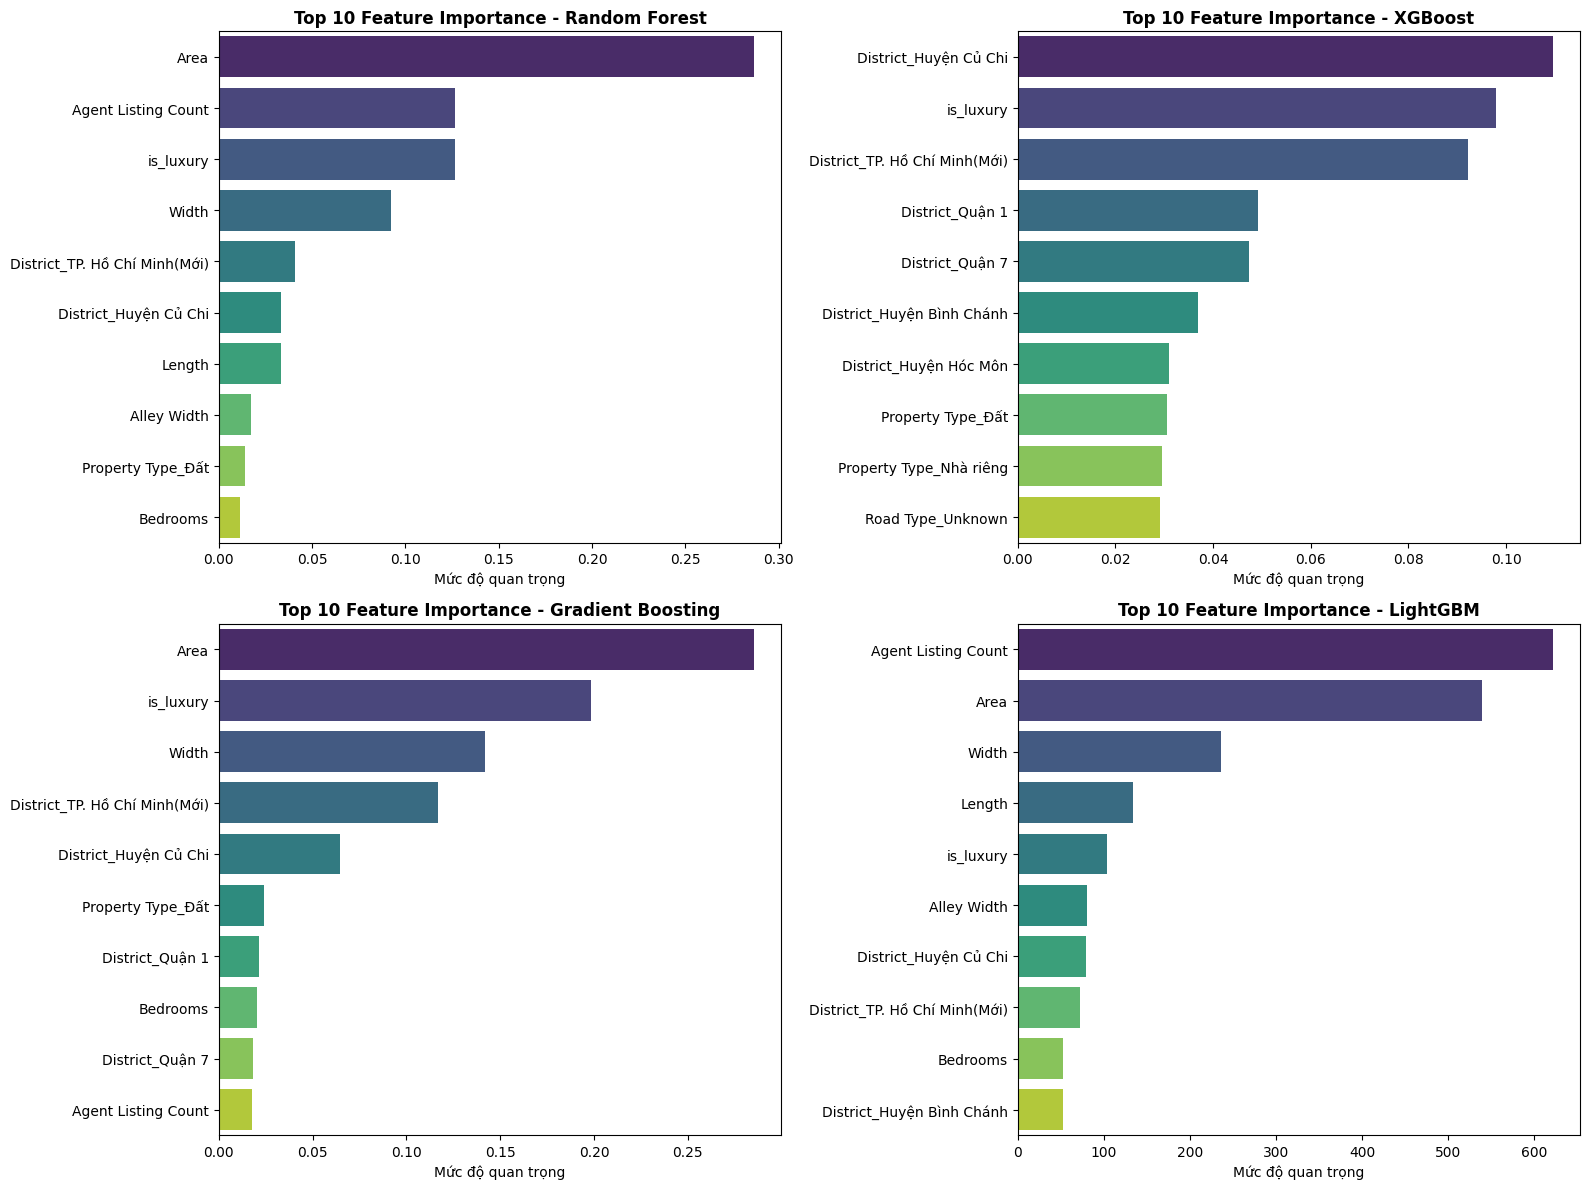

In [9]:
# Bổ sung khai báo advanced_models lấy từ all_models ở Cell 5
advanced_models = {
    'Random Forest': all_models['Random Forest'],
    'XGBoost': all_models['XGBoost'],
    'Gradient Boosting': all_models['Gradient Boosting'],
    'LightGBM': all_models['LightGBM']
}

# Cấu hình subplot 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, model) in enumerate(advanced_models.items()):
    # Lấy feature importance từ thuộc tính mô hình
    importances = model.feature_importances_
    feature_names = X_train.columns

    # Tạo DataFrame để sắp xếp và chọn ra top 10
    df_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False).head(10)

    # Vẽ biểu đồ thanh ngang
    sns.barplot(
        x='Importance',
        y='Feature',
        data=df_importance,
        ax=axes[idx],
        palette='viridis',
        hue='Feature',
        legend=False
    )
    axes[idx].set_title(f'Top 10 Feature Importance - {name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Mức độ quan trọng')
    axes[idx].set_ylabel('')

plt.tight_layout()
# Lưu biểu đồ vào folder kết quả
plt.savefig('./results/model_comparison/top_10_feature_importance.png', dpi=300)
plt.show()

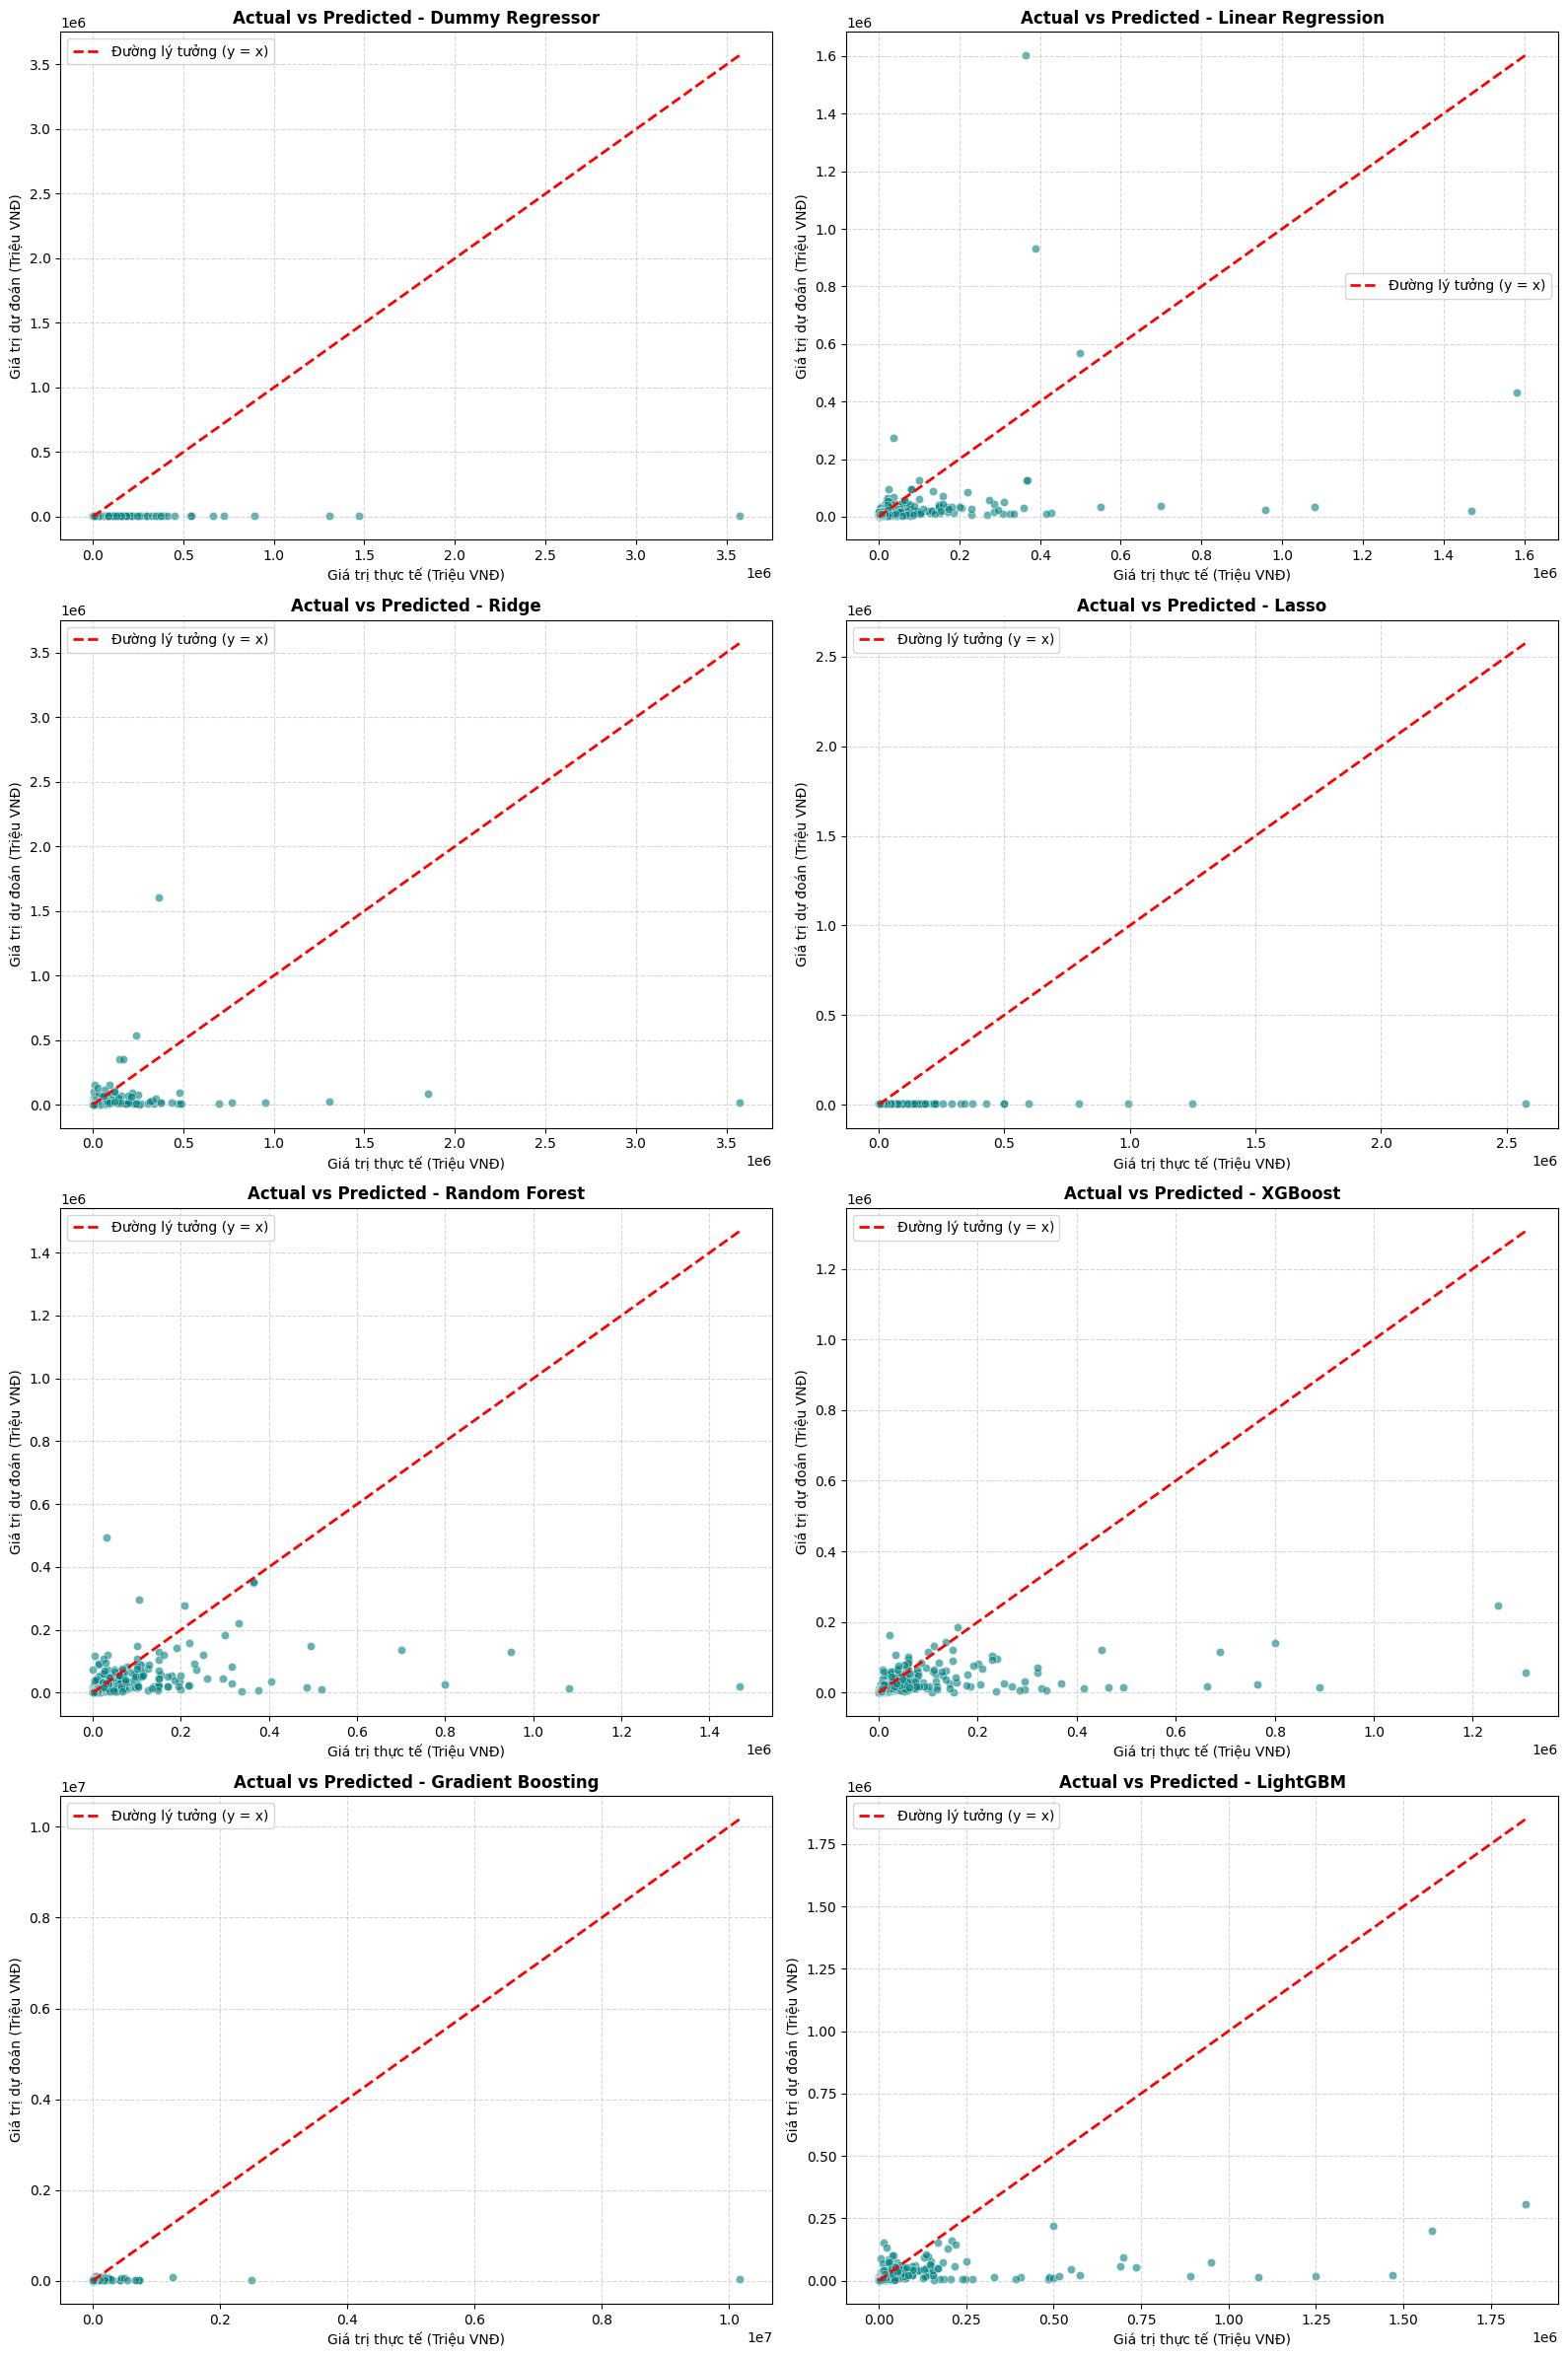

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Cấu hình subplot 4x2 để chứa đủ 8 biểu đồ
fig, axes = plt.subplots(4, 2, figsize=(16, 24))
axes = axes.flatten()

for idx, (name, pred_actual) in enumerate(predictions_dict.items()):
    # Lấy ngẫu nhiên tối đa 1000 điểm để biểu đồ không bị quá tải
    sample_size = min(1000, len(y_test_actual))
    sample_idx = np.random.choice(len(y_test_actual), sample_size, replace=False)

    actual_sampled = y_test_actual.iloc[sample_idx] if isinstance(y_test_actual, pd.Series) else y_test_actual[sample_idx]
    pred_sampled = pred_actual[sample_idx]

    sns.scatterplot(x=actual_sampled, y=pred_sampled, alpha=0.6, ax=axes[idx], color='teal')

    # Đường lý tưởng y = x
    max_val = max(actual_sampled.max(), pred_sampled.max())
    min_val = min(actual_sampled.min(), pred_sampled.min())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Đường lý tưởng (y = x)')

    axes[idx].set_title(f'Actual vs Predicted - {name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Giá trị thực tế (Triệu VNĐ)')
    axes[idx].set_ylabel('Giá trị dự đoán (Triệu VNĐ)')
    axes[idx].legend()
    axes[idx].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('./results/model_comparison/actual_vs_predicted.png', dpi=300)
plt.show()